In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import pickle
import matplotlib.pyplot as plt


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks


/content/drive/MyDrive/Colab Notebooks


In [4]:
# =========================
# PCA FUNCTION
# =========================
def apply_pca(indep_X, n):
    sc = StandardScaler()
    indep_X_scaled = sc.fit_transform(indep_X)

    pca = PCA(n_components=n)
    pca_features = pca.fit_transform(indep_X_scaled)

    return pca_features

In [5]:
# =========================
# SPLIT FUNCTION
# =========================
def split_scalar(indep_X, dep_Y):
    X_train, X_test, y_train, y_test = train_test_split(
        indep_X, dep_Y, test_size=0.25, random_state=0
    )
    return X_train, X_test, y_train, y_test

In [6]:
# =========================
# CONFUSION MATRIX + REPORT
# =========================
def cm_prediction(classifier, X_test, y_test):
    y_pred = classifier.predict(X_test)

    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import classification_report

    cm = confusion_matrix(y_test, y_pred)
    Accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    return classifier, Accuracy, report, X_test, y_test, cm


In [7]:
# =========================
# LOGISTIC REGRESSION
# =========================
def logistic(X_train, y_train, X_test, y_test):
    from sklearn.linear_model import LogisticRegression

    classifier = LogisticRegression(random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm



In [8]:
# =========================
# SVM LINEAR
# =========================
def svm_linear(X_train, y_train, X_test, y_test):
    from sklearn.svm import SVC

    classifier = SVC(kernel='linear', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm


In [9]:
# =========================
# SVM NON-LINEAR
# =========================
def svm_NL(X_train, y_train, X_test, y_test):
    from sklearn.svm import SVC

    classifier = SVC(kernel='rbf', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm


In [10]:
# =========================
# NAIVE BAYES
# =========================
def Navie(X_train, y_train, X_test, y_test):
    from sklearn.naive_bayes import GaussianNB

    classifier = GaussianNB()
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm



In [11]:
# =========================
# KNN
# =========================
def knn(X_train, y_train, X_test, y_test):
    from sklearn.neighbors import KNeighborsClassifier

    classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm



In [12]:
# =========================
# DECISION TREE
# =========================
def Decision(X_train, y_train, X_test, y_test):
    from sklearn.tree import DecisionTreeClassifier

    classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm


In [13]:
# =========================
# RANDOM FOREST
# =========================
def random(X_train, y_train, X_test, y_test):
    from sklearn.ensemble import RandomForestClassifier

    classifier = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)

    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test, y_test)
    return classifier, Accuracy, report, X_test, y_test, cm

In [14]:
# =========================
# RESULT TABLE
# =========================
def pca_Classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf):
    dataframe = pd.DataFrame(
        index=['PCA'],
        columns=['Logistic', 'SVMl', 'SVMnl', 'KNN', 'Navie', 'Decision', 'Random']
    )

    for number, idex in enumerate(dataframe.index):
        dataframe['Logistic'][idex] = acclog[number]
        dataframe['SVMl'][idex] = accsvml[number]
        dataframe['SVMnl'][idex] = accsvmnl[number]
        dataframe['KNN'][idex] = accknn[number]
        dataframe['Navie'][idex] = accnav[number]
        dataframe['Decision'][idex] = accdes[number]
        dataframe['Random'][idex] = accrf[number]

    return dataframe


In [15]:
# =========================
# LOAD DATASET
# =========================
dataset1 = pd.read_csv("Wine.csv", index_col=None)

df2 = dataset1.copy()

# Convert categorical columns to dummy
df2 = pd.get_dummies(df2, drop_first=True)

# Display available columns to help identify the correct target variable
print("Available columns after get_dummies:", df2.columns.tolist())


Available columns after get_dummies: ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline', 'Customer_Segment']


In [16]:
# Features and target
# The original error was: KeyError: "['classification_yes'] not found in axis"
# This means the column 'classification_yes' does not exist in df2.
# Please inspect the output above and replace 'your_actual_target_column' with the correct name.
# For example, if your target column is named 'Class_2', you would use:
# indep_X = df2.drop('Class_2', axis=1)
# dep_Y = df2['Class_2']

# Corrected lines using the identified target column 'Customer_Segment'
indep_X = df2.drop('Customer_Segment', axis=1)
dep_Y = df2['Customer_Segment']

In [17]:
# =========================
# APPLY PCA
# =========================
# Determine the number of components for PCA. A common choice is to retain components explaining a certain percentage of variance, or a fixed number.
# For now, let's assume we want to reduce to 2 principal components. Adjust 'n_components' as needed.
n_components = 2 # Example: You might want to analyze variance explained to choose this.
pca_data = apply_pca(indep_X, n_components)

In [18]:
# =========================
# INITIALIZE ACCURACY LISTS
# =========================
acclog = []
accsvml = []
accsvmnl = []
accknn = []
accnav = []
accdes = []
accrf = []

In [19]:
# =========================
# SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = split_scalar(pca_data, dep_Y)


In [20]:

# =========================
# TRAIN ALL MODELS
# =========================
classifier, Accuracy, report, X_test, y_test, cm = logistic(X_train, y_train, X_test, y_test)
acclog.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = svm_linear(X_train, y_train, X_test, y_test)
accsvml.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = svm_NL(X_train, y_train, X_test, y_test)
accsvmnl.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = knn(X_train, y_train, X_test, y_test)
accknn.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = Navie(X_train, y_train, X_test, y_test)
accnav.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = Decision(X_train, y_train, X_test, y_test)
accdes.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = random(X_train, y_train, X_test, y_test)
accrf.append(Accuracy)

In [24]:
def pca_Classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf):
    dataframe = pd.DataFrame({
        'Logistic': [acclog[0]],
        'SVMl': [accsvml[0]],
        'SVMnl': [accsvmnl[0]],
        'KNN': [accknn[0]],
        'Navie': [accnav[0]],
        'Decision': [accdes[0]],
        'Random': [accrf[0]]
    }, index=['PCA'])

    return dataframe

In [28]:
def pca_classification(acclog, accsvm1, accsvmn1, accknn, accnav, accdes, accrf):
    dataframe = pd.DataFrame({
        'Logistic': [acclog[0]],
        'SVM1': [accsvm1[0]],
        'SVMn1': [accsvmn1[0]],
        'KNN': [accknn[0]],
        'Navie': [accnav[0]],
        'Decision': [accdes[0]],
        'Random': [accrf[0]]
    }, index=['PCA'])

    return dataframe

In [29]:
print(result)

     Logistic      SVMl     SVMnl       KNN     Navie  Decision    Random
PCA  0.977778  0.977778  0.977778  0.977778  0.977778  0.977778  0.977778



Logistic Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

SVM Linear Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

SVM RBF Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

KNN Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Naive Bayes Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Decision Tree Confusion Matrix:
[[14  0  0]
 [ 1 13  0]
 [ 0  0  8]]

Random Forest Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Final Results:
           Model  Accuracy  Precision    Recall  F1 Score
0       Logistic  1.000000   1.000000  1.000000  1.000000
1     SVM Linear  1.000000   1.000000  1.000000  1.000000
2        SVM RBF  1.000000   1.000000  1.000000  1.000000
3            KNN  1.000000   1.000000  1.000000  1.000000
4    Naive Bayes  1.000000   1.000000  1.000000  1.000000
5  Decision Tree  0.972222   0.974074  0.972222  0.972187
6  Random Forest  1.000000   1.000000  1.000000  1.000000


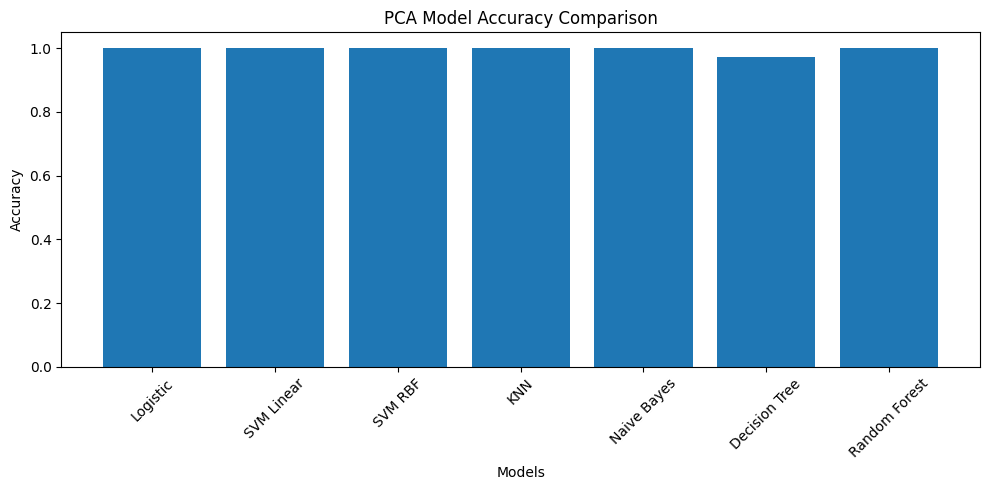

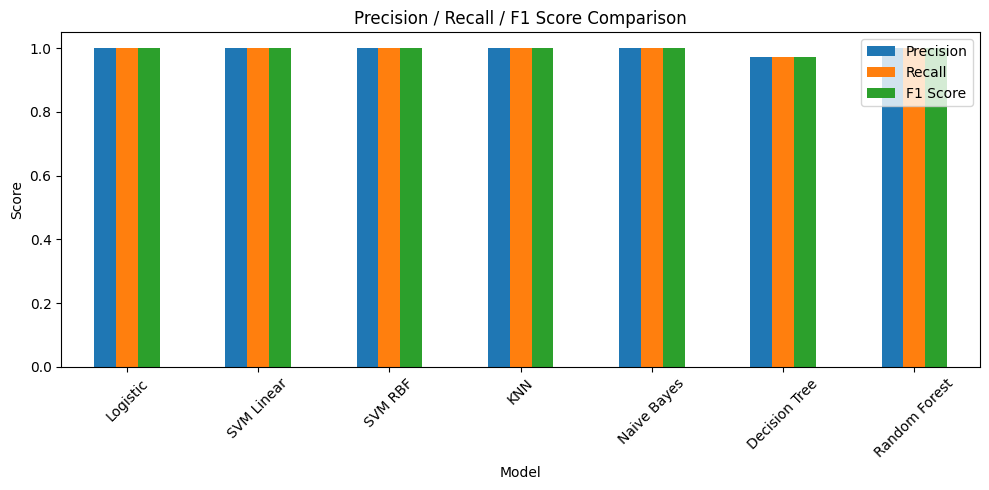

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =========================
# 1. LOAD DATASET
# =========================
df = pd.read_csv("Wine.csv")   # change your file name

# Last column = target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# =========================
# 2. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. SCALING
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 4. PCA
# =========================
pca = PCA(n_components=2)   # change if needed
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# =========================
# 5. MODELS
# =========================
models = {
    "Logistic": LogisticRegression(),
    "SVM Linear": SVC(kernel='linear'),
    "SVM RBF": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# =========================
# 6. TRAIN + PREDICT + METRICS
# =========================
results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name} Confusion Matrix:")
    print(cm)

# =========================
# 7. RESULTS TABLE
# =========================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\nFinal Results:")
print(results_df)

# =========================
# 8. ACCURACY BAR CHART
# =========================
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("PCA Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 9. METRICS BAR CHART
# =========================
results_df.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10,5))
plt.title("Precision / Recall / F1 Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Wine.csv")

# X = features only (exclude target)
X = df.drop("Customer_Segment", axis=1)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Loadings = exact PC1 and PC2 coefficients
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print("=== EXACT PC1 and PC2 LOADINGS ===")
print(loadings)

print("\n=== EXPLAINED VARIANCE RATIO ===")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total (PC1+PC2):", pca.explained_variance_ratio_.sum())

=== EXACT PC1 and PC2 LOADINGS ===
                           PC1       PC2
Alcohol               0.144329  0.483652
Malic_Acid           -0.245188  0.224931
Ash                  -0.002051  0.316069
Ash_Alcanity         -0.239320 -0.010591
Magnesium             0.141992  0.299634
Total_Phenols         0.394661  0.065040
Flavanoids            0.422934 -0.003360
Nonflavanoid_Phenols -0.298533  0.028779
Proanthocyanins       0.313429  0.039302
Color_Intensity      -0.088617  0.529996
Hue                   0.296715 -0.279235
OD280                 0.376167 -0.164496
Proline               0.286752  0.364903

=== EXPLAINED VARIANCE RATIO ===
PC1: 0.3619884809992633
PC2: 0.1920749025700894
Total (PC1+PC2): 0.5540633835693527


In [40]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("Wine.csv")
X = df.drop("Customer_Segment", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"])

print(loadings.round(4))

print("\nPC1 Formula:")
print(" + ".join([f"({loadings.loc[col, 'PC1']:.4f} * {col})" for col in X.columns]))

print("\nPC2 Formula:")
print(" + ".join([f"({loadings.loc[col, 'PC2']:.4f} * {col})" for col in X.columns]))

print("\nExplained Variance Ratio:")
print("PC1 =", round(pca.explained_variance_ratio_[0], 4))
print("PC2 =", round(pca.explained_variance_ratio_[1], 4))
print("Total =", round(sum(pca.explained_variance_ratio_), 4))

                         PC1     PC2
Alcohol               0.1443  0.4837
Malic_Acid           -0.2452  0.2249
Ash                  -0.0021  0.3161
Ash_Alcanity         -0.2393 -0.0106
Magnesium             0.1420  0.2996
Total_Phenols         0.3947  0.0650
Flavanoids            0.4229 -0.0034
Nonflavanoid_Phenols -0.2985  0.0288
Proanthocyanins       0.3134  0.0393
Color_Intensity      -0.0886  0.5300
Hue                   0.2967 -0.2792
OD280                 0.3762 -0.1645
Proline               0.2868  0.3649

PC1 Formula:
(0.1443 * Alcohol) + (-0.2452 * Malic_Acid) + (-0.0021 * Ash) + (-0.2393 * Ash_Alcanity) + (0.1420 * Magnesium) + (0.3947 * Total_Phenols) + (0.4229 * Flavanoids) + (-0.2985 * Nonflavanoid_Phenols) + (0.3134 * Proanthocyanins) + (-0.0886 * Color_Intensity) + (0.2967 * Hue) + (0.3762 * OD280) + (0.2868 * Proline)

PC2 Formula:
(0.4837 * Alcohol) + (0.2249 * Malic_Acid) + (0.3161 * Ash) + (-0.0106 * Ash_Alcanity) + (0.2996 * Magnesium) + (0.0650 * Total_Phenols) + (

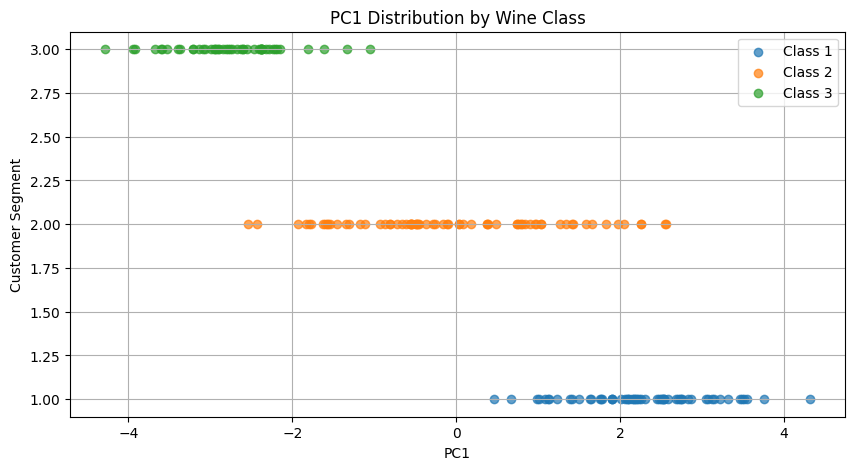

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv("Wine.csv")

# Features and target
X = df.drop("Customer_Segment", axis=1)
y = df["Customer_Segment"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Customer_Segment"] = y

# -------------------------
# PC1 ONLY GRAPH
# -------------------------
plt.figure(figsize=(10,5))

for segment in pca_df["Customer_Segment"].unique():
    subset = pca_df[pca_df["Customer_Segment"] == segment]
    plt.scatter(subset["PC1"], [segment]*len(subset), label=f"Class {segment}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("Customer Segment")
plt.title("PC1 Distribution by Wine Class")
plt.legend()
plt.grid(True)
plt.show()

PC1 mainly influenced by:
Flavanoids
Total_Phenols
OD280
Proanthocyanins
Hue
Proline

👉 So PC1 mostly represents:

Phenolic / chemical quality pattern
PC2 mainly influenced by:
Color_Intensity
Alcohol
Proline
Ash
Magnesium

👉 So PC2 mostly represents:

Color + alcohol strength pattern

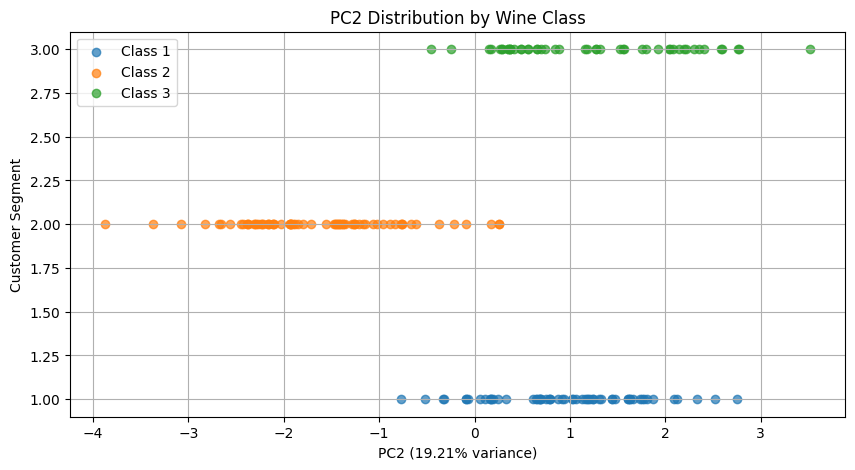

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv("Wine.csv")

# Features and target
X = df.drop("Customer_Segment", axis=1)
y = df["Customer_Segment"]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Customer_Segment"] = y

# -------------------------
# PC2 ONLY GRAPH
# -------------------------
plt.figure(figsize=(10,5))

for segment in sorted(pca_df["Customer_Segment"].unique()):
    subset = pca_df[pca_df["Customer_Segment"] == segment]
    plt.scatter(
        subset["PC2"],               # X-axis = PC2
        [segment] * len(subset),     # Y-axis = class
        label=f"Class {segment}",
        alpha=0.7
    )

plt.xlabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.ylabel("Customer Segment")
plt.title("PC2 Distribution by Wine Class")
plt.legend()
plt.grid(True)
plt.show()

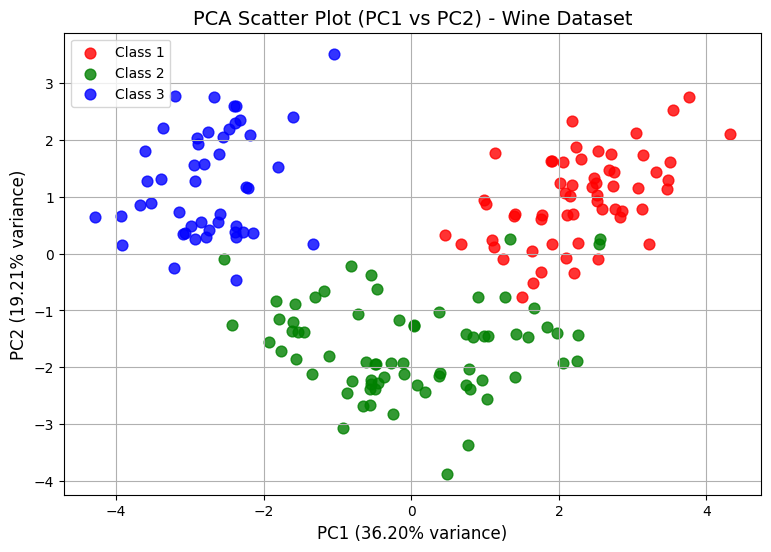

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Wine.csv")

# Features and target
X = df.drop("Customer_Segment", axis=1)
y = df["Customer_Segment"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(9,6))

colors = ['red', 'green', 'blue']

for i, segment in enumerate(sorted(y.unique())):
    plt.scatter(
        X_pca[y == segment, 0],
        X_pca[y == segment, 1],
        label=f"Class {segment}",
        alpha=0.8,
        s=60,
        c=colors[i]
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)", fontsize=12)
plt.title("PCA Scatter Plot (PC1 vs PC2) - Wine Dataset", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

PC1 Variance: 36.20%
PC2 Variance: 19.21%
Total Variance (PC1 + PC2): 55.41%


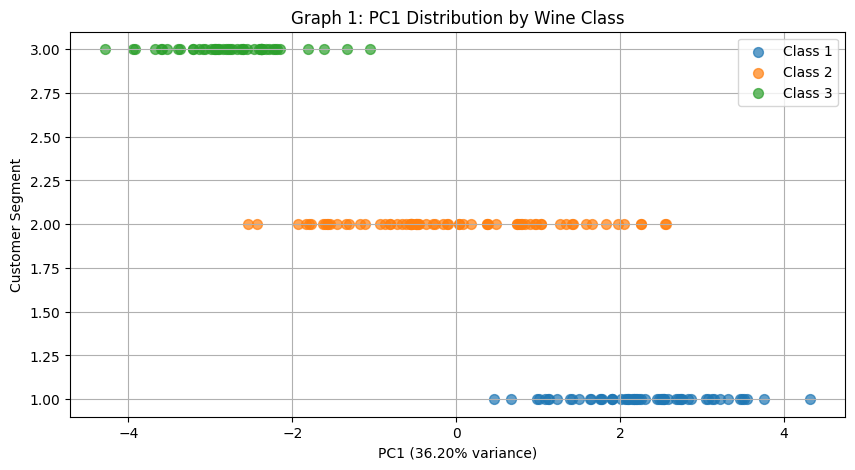

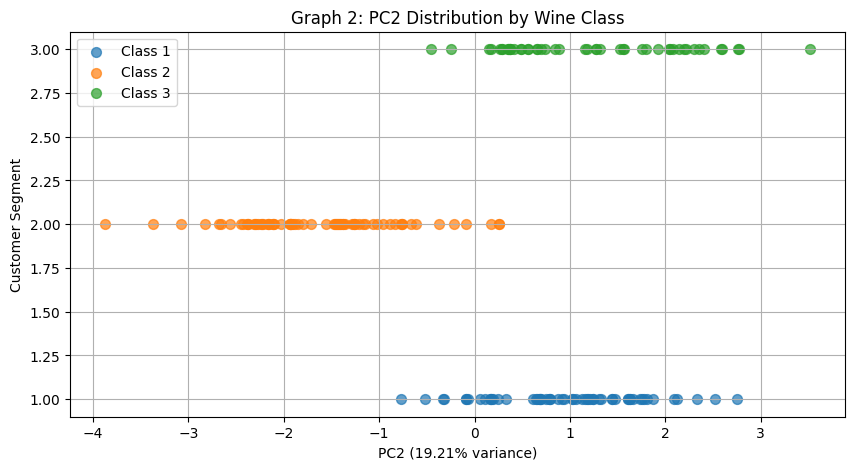

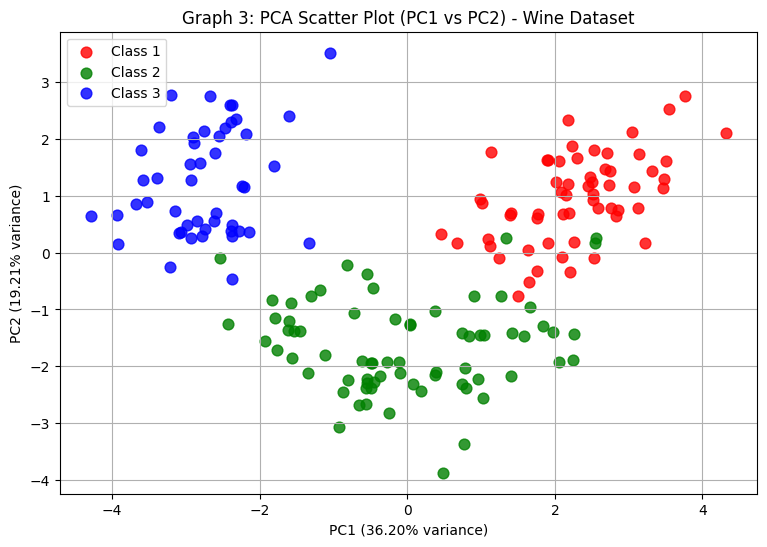

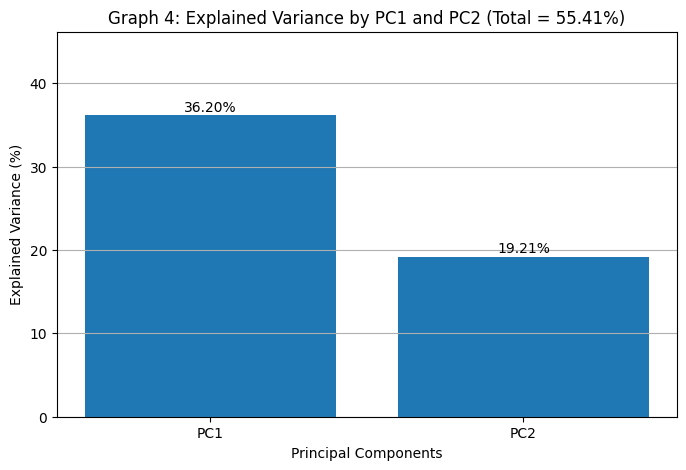

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# 1. LOAD DATASET
# =========================
df = pd.read_csv("Wine.csv")

# Features and target
X = df.drop("Customer_Segment", axis=1)
y = df["Customer_Segment"]

# =========================
# 2. STANDARDIZE FEATURES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 3. APPLY PCA (2 COMPONENTS)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Customer_Segment"] = y

# Explained variance
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100
total_var = pc1_var + pc2_var

print(f"PC1 Variance: {pc1_var:.2f}%")
print(f"PC2 Variance: {pc2_var:.2f}%")
print(f"Total Variance (PC1 + PC2): {total_var:.2f}%")

# =========================
# 4. GRAPH 1 - PC1 DISTRIBUTION
# =========================
plt.figure(figsize=(10, 5))

for segment in sorted(pca_df["Customer_Segment"].unique()):
    subset = pca_df[pca_df["Customer_Segment"] == segment]
    plt.scatter(
        subset["PC1"],
        [segment] * len(subset),
        label=f"Class {segment}",
        alpha=0.7,
        s=50
    )

plt.xlabel(f"PC1 ({pc1_var:.2f}% variance)")
plt.ylabel("Customer Segment")
plt.title("Graph 1: PC1 Distribution by Wine Class")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 5. GRAPH 2 - PC2 DISTRIBUTION
# =========================
plt.figure(figsize=(10, 5))

for segment in sorted(pca_df["Customer_Segment"].unique()):
    subset = pca_df[pca_df["Customer_Segment"] == segment]
    plt.scatter(
        subset["PC2"],
        [segment] * len(subset),
        label=f"Class {segment}",
        alpha=0.7,
        s=50
    )

plt.xlabel(f"PC2 ({pc2_var:.2f}% variance)")
plt.ylabel("Customer Segment")
plt.title("Graph 2: PC2 Distribution by Wine Class")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 6. GRAPH 3 - PC1 vs PC2 SCATTER PLOT
# =========================
plt.figure(figsize=(9, 6))

colors = ['red', 'green', 'blue']

for i, segment in enumerate(sorted(pca_df["Customer_Segment"].unique())):
    subset = pca_df[pca_df["Customer_Segment"] == segment]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Class {segment}",
        alpha=0.8,
        s=60,
        c=colors[i]
    )

plt.xlabel(f"PC1 ({pc1_var:.2f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% variance)")
plt.title("Graph 3: PCA Scatter Plot (PC1 vs PC2) - Wine Dataset")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 7. GRAPH 4 - EXPLAINED VARIANCE BAR CHART
# =========================
plt.figure(figsize=(8, 5))

components = ["PC1", "PC2"]
variances = [pc1_var, pc2_var]

bars = plt.bar(components, variances)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}%",
        ha='center'
    )

plt.ylim(0, max(variances) + 10)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance (%)")
plt.title(f"Graph 4: Explained Variance by PC1 and PC2 (Total = {total_var:.2f}%)")
plt.grid(axis='y')
plt.show()

Graph 1 → PC1 Distribution
Shows class-wise spread on PC1
PC1 = 36.20% variance
Graph 2 → PC2 Distribution
Shows class-wise spread on PC2
PC2 = 19.21% variance
Graph 3 → PC1 vs PC2 Scatter Plot
Best graph for project / viva
Shows class separation visually
Graph 4 → Explained Variance Chart
Shows how much variance:
PC1 captures
PC2 captures
Total = 55.41%

In [47]:
print(result)

     Logistic      SVMl     SVMnl       KNN     Navie  Decision    Random
PCA  0.977778  0.977778  0.977778  0.977778  0.977778  0.977778  0.977778


Original Data (13 features)
        ↓
StandardScaler
        ↓
PCA
        ↓
PC1 + PC2
        ↓
Train/Test Split
        ↓
Models (Logistic, SVM, KNN, etc.)
        ↓
Prediction of Customer_Segment
        ↓
Compare with actual y_test
        ↓
Accuracy = 0.977778